In [1]:
# KMeans algorithm: unsupervised algorithm. Usually used for finding natural groups based feature values. 
# e.g. used in segmentation task in markering

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/iris.csv")
df = df.drop(columns = "Id")
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


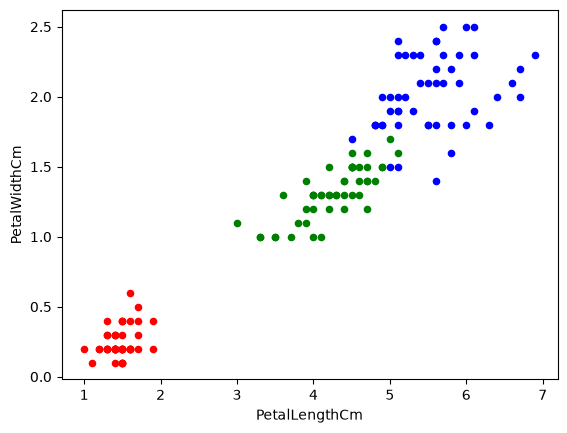

In [6]:
fig, ax = plt.subplots()

colors = ['red', 'green','blue']
for i, s in enumerate(df.Species.unique()):
    df[df.Species == s].plot.scatter("PetalLengthCm", "PetalWidthCm", color = colors[i], ax = ax)

In [4]:
features = ['PetalLengthCm', 'PetalWidthCm']
X = df[features]
X

,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [7]:
from sklearn import preprocessing

In [8]:
scaler = preprocessing.StandardScaler()
X_std = scaler.fit_transform(X)

In [9]:
X_std

array([[-1.34127240e+00, -1.31297673e+00],
       [-1.34127240e+00, -1.31297673e+00],
       [-1.39813811e+00, -1.31297673e+00],
       [-1.28440670e+00, -1.31297673e+00],
       [-1.34127240e+00, -1.31297673e+00],
       [-1.17067529e+00, -1.05003079e+00],
       [-1.34127240e+00, -1.18150376e+00],
       [-1.28440670e+00, -1.31297673e+00],
       [-1.34127240e+00, -1.31297673e+00],
       [-1.28440670e+00, -1.44444970e+00],
       [-1.28440670e+00, -1.31297673e+00],
       [-1.22754100e+00, -1.31297673e+00],
       [-1.34127240e+00, -1.44444970e+00],
       [-1.51186952e+00, -1.44444970e+00],
       [-1.45500381e+00, -1.31297673e+00],
       [-1.28440670e+00, -1.05003079e+00],
       [-1.39813811e+00, -1.05003079e+00],
       [-1.34127240e+00, -1.18150376e+00],
       [-1.17067529e+00, -1.18150376e+00],
       [-1.28440670e+00, -1.18150376e+00],
       [-1.17067529e+00, -1.31297673e+00],
       [-1.28440670e+00, -1.05003079e+00],
       [-1.56873522e+00, -1.31297673e+00],
       [-1.

In [10]:
pd.DataFrame(X_std).describe()

,0,1
count,1.500000e+02,1.500000e+02
mean,3.315866e-16,-2.842171e-16
std,1.003350e+00,1.003350e+00
min,-1.568735e+00,-1.444450e+00
25%,-1.227541e+00,-1.181504e+00
50%,3.362659e-01,1.332259e-01
75%,7.627586e-01,7.905908e-01
max,1.786341e+00,1.710902e+00


In [12]:
from sklearn import cluster

In [13]:
est = cluster.KMeans(n_clusters=3,max_iter=100)
y_pred = est.fit_predict(X_std)

In [14]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

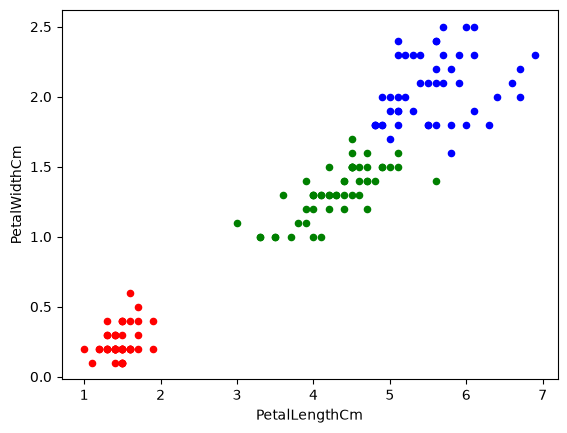

In [18]:
fig, ax = plt.subplots()

colors = ['red', 'green','blue']
for i in range(3):
    a = X[y_pred == i]
    a = pd.DataFrame(a, columns= features)
    a.plot.scatter(0, 1, color = colors[i], ax = ax)

Text(0.5, 1.0, 'Kmean clustering (k=3)')

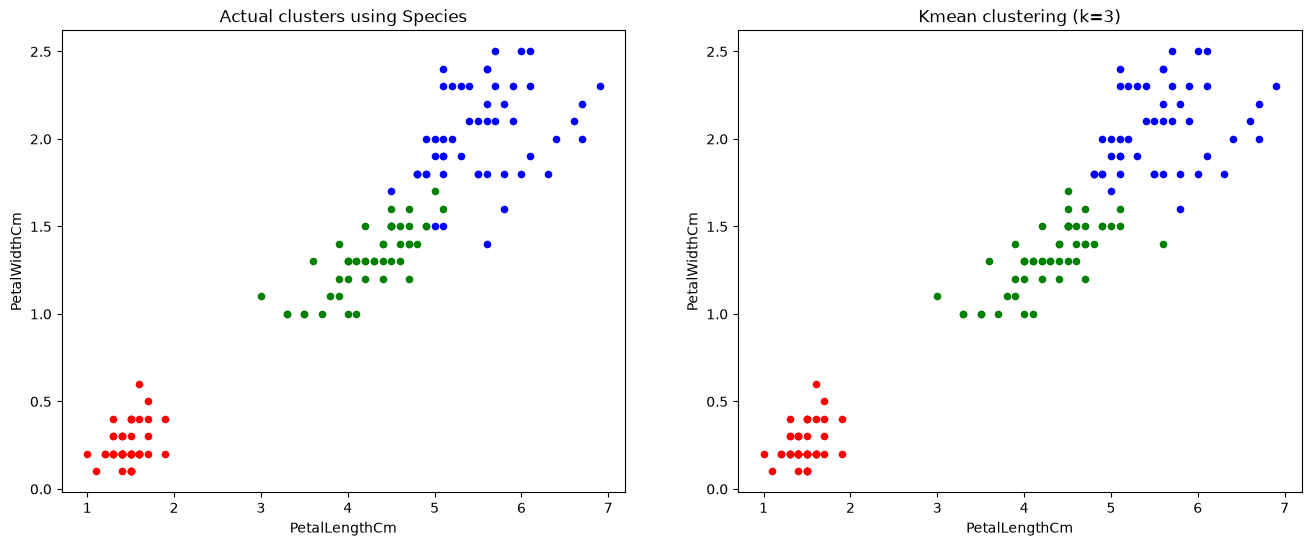

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (16, 6))


colors = ['red', 'green','blue']
for i, s in enumerate(df.Species.unique()):
    df[df.Species == s].plot.scatter("PetalLengthCm", "PetalWidthCm", color = colors[i], ax = axes[0])


colors = ['red', 'green','blue']
for i in range(3):
    a = X[y_pred == i]
    a = pd.DataFrame(a, columns= features)
    a.plot.scatter(0, 1, color = colors[i], ax = axes[1])

axes[0].set_title('Actual clusters using Species')
axes[1].set_title('Kmean clustering (k=3)')

In [23]:
from sklearn import metrics

In [24]:
metrics.homogeneity_score(df.Species, y_pred)

0.8639756867013153